In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = {
"text":[
"Win a free iPhone now",
"Meeting at 10am tomorrow",
"Congratulations you won money",
"Let's finish the project",
"Claim your free prize today"
],
"label":[1,0,1,0,1]
}

df = pd.DataFrame(data)

X_train,X_test,y_train,y_test = train_test_split(df["text"],df["label"],test_size=0.2)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec,y_train)

pred = model.predict(X_test_vec)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 1.0


In [2]:
# Load a larger real-world spam dataset

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df_real = pd.read_csv(
    url,
    sep="\t",
    header=None,
    names=["label", "text"]
)

print("Dataset shape:", df_real.shape)
print()
print(df_real.head())
print()
print(df_real["label"].value_counts())

Dataset shape: (5572, 2)

  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

label
ham     4825
spam     747
Name: count, dtype: int64


In [3]:
# Prepare the real dataset

X_real = df_real["text"]
y_real = df_real["label"]

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real,
    y_real,
    test_size=0.2,
    random_state=42,
    stratify=y_real
)

print("Training samples:", len(X_train_real))
print("Testing samples:", len(X_test_real))

print("\nTraining labels:")
print(y_train_real.value_counts())

print("\nTesting labels:")
print(y_test_real.value_counts())

Training samples: 4457
Testing samples: 1115

Training labels:
label
ham     3859
spam     598
Name: count, dtype: int64

Testing labels:
label
ham     966
spam    149
Name: count, dtype: int64


In [4]:
# Convert the real email/SMS text into numerical features

vectorizer_real = TfidfVectorizer(stop_words="english")

X_train_vec_real = vectorizer_real.fit_transform(X_train_real)
X_test_vec_real = vectorizer_real.transform(X_test_real)

print("Training matrix shape:", X_train_vec_real.shape)
print("Testing matrix shape:", X_test_vec_real.shape)
print("Number of features:", len(vectorizer_real.get_feature_names_out()))

Training matrix shape: (4457, 7403)
Testing matrix shape: (1115, 7403)
Number of features: 7403


In [5]:
# Train the spam classification model

from sklearn.naive_bayes import MultinomialNB

model_real = MultinomialNB()
model_real.fit(X_train_vec_real, y_train_real)

print("Model training completed successfully!")

Model training completed successfully!


In [6]:
# Evaluate the model

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred_real = model_real.predict(X_test_vec_real)

accuracy_real = accuracy_score(y_test_real, y_pred_real)

print(f"Accuracy: {accuracy_real:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_real, y_pred_real))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_real, y_pred_real))

Accuracy: 0.9704

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115


Confusion Matrix:
[[966   0]
 [ 33 116]]


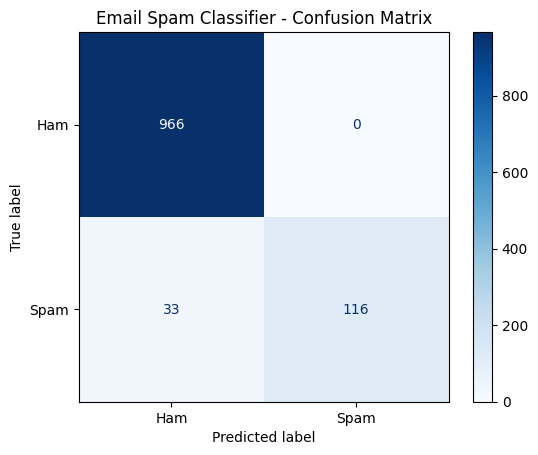

In [7]:
# Visualize the confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_real,
    y_pred_real,
    display_labels=["Ham", "Spam"],
    cmap="Blues"
)

plt.title("Email Spam Classifier - Confusion Matrix")
plt.show()

In [8]:
# Test the classifier with your own message

def classify_message(message):
    message_vec = vectorizer_real.transform([message])
    prediction = model_real.predict(message_vec)[0]

    if prediction == "spam":
        return "🚨 SPAM"
    else:
        return "✅ HAM (Not Spam)"

message = input("Enter a message: ")

result = classify_message(message)

print("\nPrediction:", result)

Enter a message: Congratulations! You won a free iPhone. Click here to claim your prize now!

Prediction: 🚨 SPAM


## Final Results

The improved Email Spam Classifier was trained using the SMS Spam Collection dataset containing 5,572 labeled messages.

### Model Performance

- **Accuracy:** 97.04%
- **Ham Precision:** 97%
- **Ham Recall:** 100%
- **Spam Precision:** 100%
- **Spam Recall:** 78%
- **Spam F1-Score:** 88%

### Confusion Matrix

The model correctly classified:
- 966 ham messages as ham
- 116 spam messages as spam

It misclassified:
- 33 spam messages as ham
- 0 ham messages as spam

### Conclusion

The TF-IDF and Multinomial Naive Bayes model achieved strong overall performance on unseen test data. The model was particularly precise when identifying spam, although further improvements could focus on increasing spam recall and reducing missed spam messages.